Veri yükleniyor...
Veri okundu.

Toplam ülke/location sayısı: 248

Ülkeler işleniyor...
Toplam işlenen ülke: 248

İstenen ülke sayısı: 201

PCA hesaplanıyor...


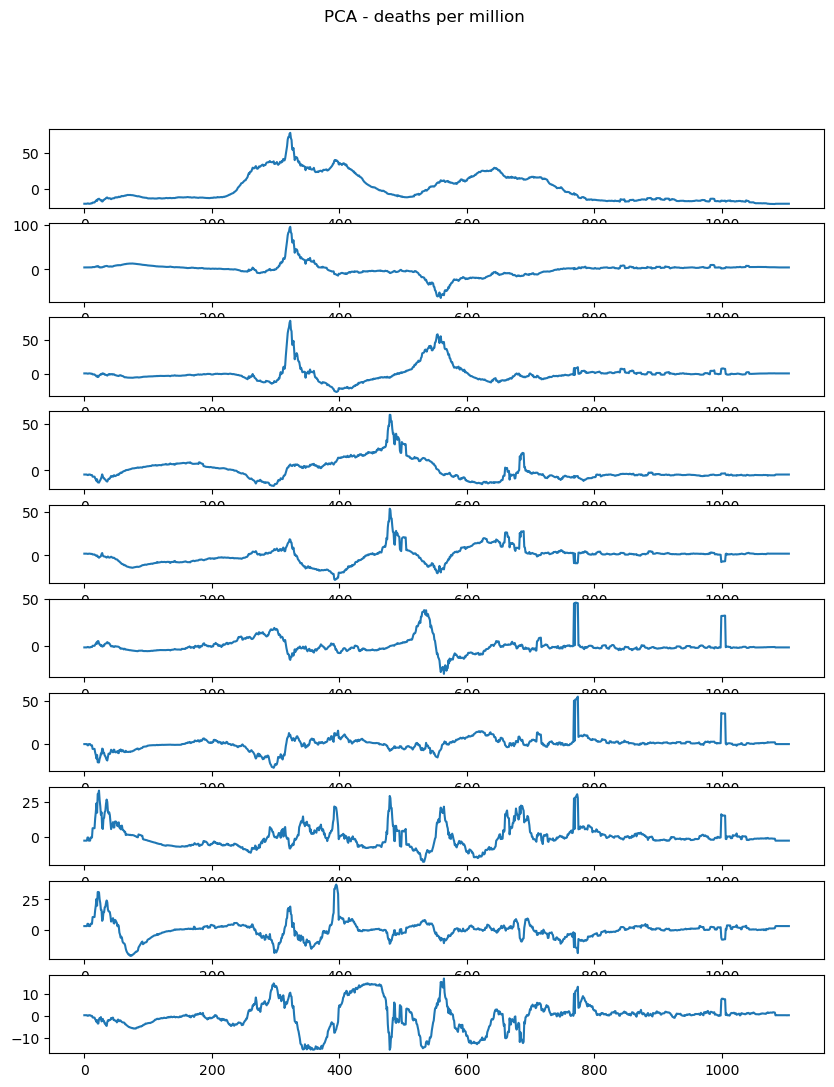

ICA hesaplanıyor...


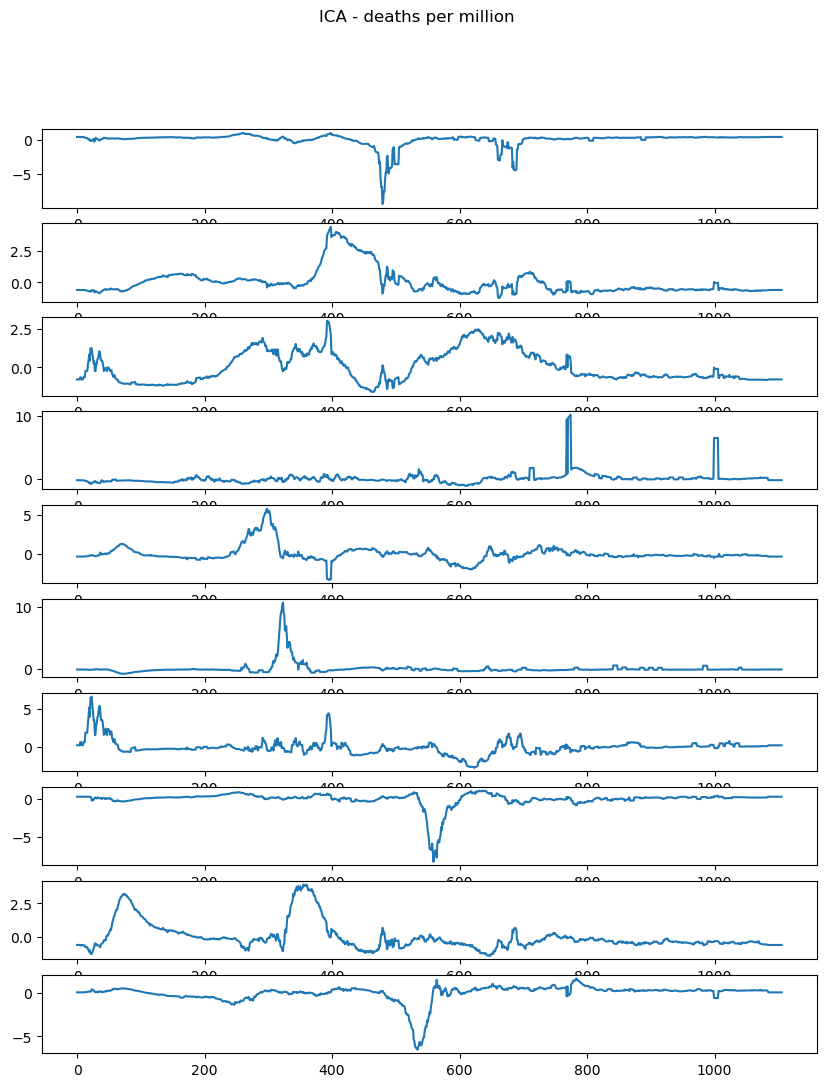

NMF hesaplanıyor...


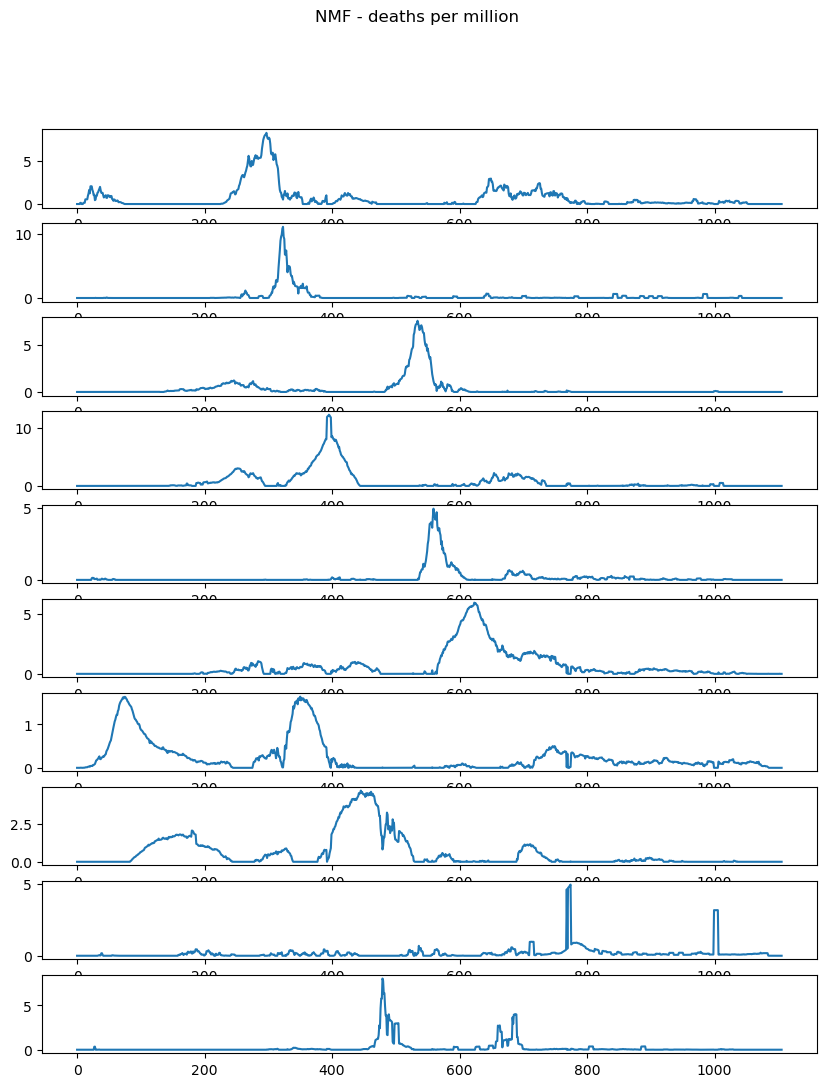

In [15]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA, FastICA, NMF
from sklearn.cluster import KMeans, SpectralClustering
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1) Veri Okuma
# ----------------------------------------------------------
print("Veri yükleniyor...")
data = pd.read_csv("owid-covid-data.csv", parse_dates=["date"])
print("Veri okundu.\n")

# ----------------------------------------------------------
# 2) Ülke isimlerini alma
# ----------------------------------------------------------
all_countries = data["location"].unique().tolist()
print("Toplam ülke/location sayısı:", len(all_countries))

# ----------------------------------------------------------
# 3) Her ülke için ölüm verilerini toplama
# ----------------------------------------------------------
country_list = []
death_matrix = []
death_per_million_matrix = []

print("\nÜlkeler işleniyor...")

for country in all_countries:
    country_data = data[data["location"] == country]

    if len(country_data) == 0:
        continue
    
    deaths = country_data["new_deaths_smoothed"].fillna(0).values
    deaths_pm = country_data["new_deaths_smoothed_per_million"].fillna(0).values

    country_list.append(country)
    death_matrix.append(deaths)
    death_per_million_matrix.append(deaths_pm)

print("Toplam işlenen ülke:", len(country_list))

# ----------------------------------------------------------
# 4) Serileri eşit uzunluğa pad etme
# ----------------------------------------------------------
max_len = max(len(x) for x in death_matrix)

def pad_series(series, target_len):
    pad = target_len - len(series)
    return np.pad(series, (0, pad), constant_values=0)

death_matrix = np.array([pad_series(x, max_len) for x in death_matrix])
death_per_million_matrix = np.array([pad_series(x, max_len) for x in death_per_million_matrix])

# MATLAB uyumu: satır = zaman, sütun = ülke
death_pm = death_per_million_matrix.T

# ----------------------------------------------------------
# 5) Filtre: İstenmeyen lokasyonlar
# ----------------------------------------------------------
unwanted = [
"Lower middle income","High income","Low income","Asia","European Union","Europe","Africa",
"Europa","World","South America","Upper middle income","North America","Vanuatu","Vatican",
"United States Virgin Islands","Turkmenistan","Turks and Caicos Islands","Tuvalu","Tokelau",
"Sint Maarten (Dutch part)","Saint Helena","Saint Pierre and Miquelon","Puerto Rico",
"Pitcairn","Palau","Northern Cyprus","Northern Ireland","Northern Mariana Islands","Niue",
"North Korea","Nauru","Montserrat","Jersey","International","Guernsey","Guam","Greenland",
"Falkland Islands","Faeroe Islands","England","Cook Islands","Cayman Islands","Bhutan",
"Anguilla","Scotland","Wales","Wallis and Futuna","Western Sahara"
]

keep_mask = [c not in unwanted for c in country_list]
country_list = np.array(country_list)[keep_mask]
death_pm = death_pm[:, keep_mask]

print("\nİstenen ülke sayısı:", len(country_list))

# ----------------------------------------------------------
# 6) PCA
# ----------------------------------------------------------
print("\nPCA hesaplanıyor...")
pca = PCA(n_components=10)
pca_scores = pca.fit_transform(death_pm)

plt.figure(figsize=(10,12))
for i in range(10):
    plt.subplot(10,1,i+1)
    plt.plot(pca_scores[:, i])
plt.suptitle("PCA - deaths per million")
plt.show()

# ----------------------------------------------------------
# 7) ICA (RICA dengi)
# ----------------------------------------------------------
print("ICA hesaplanıyor...")
ica = FastICA(n_components=10, random_state=0)
ica_scores = ica.fit_transform(death_pm)

plt.figure(figsize=(10,12))
for i in range(10):
    plt.subplot(10,1,i+1)
    plt.plot(ica_scores[:, i])
plt.suptitle("ICA - deaths per million")
plt.show()

# ----------------------------------------------------------
# 8) NMF
# ----------------------------------------------------------
print("NMF hesaplanıyor...")
nmf = NMF(n_components=10, init="random", random_state=0)
W = nmf.fit_transform(death_pm)
H = nmf.components_

plt.figure(figsize=(10,12))
for i in range(10):
    plt.subplot(10,1,i+1)
    plt.plot(W[:, i])
plt.suptitle("NMF - deaths per million")
plt.show()



In [16]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA, FastICA, NMF
from sklearn.cluster import SpectralClustering, KMeans
import matplotlib.pyplot as plt

# ===================== DATA LOAD =====================
print("Veri yükleniyor...")
data = pd.read_csv("owid-covid-data.csv", parse_dates=["date"])
print("Veri okundu.\n")

# ===================== COUNTRY LIST =====================
all_countries = data["location"].unique().tolist()

death_matrix = []
death_pm_matrix = []
country_list = []

print("Ülkeler işleniyor...")

for country in all_countries:
    df = data[data["location"] == country]

    if df.empty:
        continue

    deaths_pm = df["new_deaths_smoothed_per_million"].fillna(0).values
    deaths = df["new_deaths_smoothed"].fillna(0).values

    country_list.append(country)
    death_matrix.append(deaths)
    death_pm_matrix.append(deaths_pm)

# ===================== PAD TIME SERIES =====================
max_len = max(len(x) for x in death_matrix)

def pad(x, L):
    return np.pad(x, (0, L - len(x)), constant_values=0)

death_pm_matrix = np.array([pad(x, max_len) for x in death_pm_matrix])

# Ülke = sütun, zaman = satır
death_pm = death_pm_matrix.T

# ===================== REMOVE AGGREGATE REGIONS =====================
unwanted = [
"Lower middle income","High income","Low income","Asia","European Union","Europe","Africa",
"Europa","World","South America","Upper middle income","North America","Vanuatu","Vatican",
"United States Virgin Islands","Turkmenistan","Turks and Caicos Islands","Tuvalu","Tokelau",
"Sint Maarten (Dutch part)","Saint Helena","Saint Pierre and Miquelon","Puerto Rico",
"Pitcairn","Palau","Northern Cyprus","Northern Ireland","Northern Mariana Islands","Niue",
"North Korea","Nauru","Montserrat","Jersey","International","Guernsey","Guam","Greenland",
"Falkland Islands","Faeroe Islands","England","Cook Islands","Cayman Islands","Bhutan",
"Anguilla","Scotland","Wales","Wallis and Futuna","Western Sahara"
]

mask = [c not in unwanted for c in country_list]
country_list = np.array(country_list)[mask]
death_pm = death_pm[:, mask]

print("Temizlenen ülke sayısı:", len(country_list))

# ===================== PCA =====================
print("\nPCA hesaplanıyor...")
pca = PCA(n_components=10)
pca_scores = pca.fit_transform(death_pm.T)

# ===================== ICA =====================
print("ICA hesaplanıyor...")
ica = FastICA(n_components=10, random_state=0)
ica_scores = ica.fit_transform(death_pm.T)

# ===================== NMF =====================
print("NMF hesaplanıyor...")
nmf = NMF(n_components=10, init="random", random_state=0)
W = nmf.fit_transform(death_pm.T)   # use W (countries x components)

# ===================== CLUSTERING =====================
CLUSTERS = 5

print(f"\nKümeleme yapılıyor ({CLUSTERS} cluster)...")

spectral_pca = SpectralClustering(n_clusters=CLUSTERS, affinity='rbf', random_state=0)
labels_pca = spectral_pca.fit_predict(pca_scores)

spectral_ica = SpectralClustering(n_clusters=CLUSTERS, affinity='rbf', random_state=0)
labels_ica = spectral_ica.fit_predict(ica_scores)

spectral_nmf = SpectralClustering(n_clusters=CLUSTERS, affinity='rbf', random_state=0)
labels_nmf = spectral_nmf.fit_predict(W)

# KMeans (karşılaştırma için)
km = KMeans(n_clusters=CLUSTERS, random_state=0)
labels_km = km.fit_predict(death_pm.T)

# ===================== PRINT CLUSTERS =====================
def print_clusters(labels, title):
    print("\n===== {} =====".format(title))
    for k in np.unique(labels):
        members = country_list[labels == k]
        print(f"\nCluster {k}:")
        for m in members:
            print(" ", m)

print_clusters(labels_pca, "PCA Clusters")
print_clusters(labels_ica, "ICA Clusters")
print_clusters(labels_nmf, "NMF Clusters")
print_clusters(labels_km, "KMeans Clusters")



Veri yükleniyor...
Veri okundu.

Ülkeler işleniyor...
Temizlenen ülke sayısı: 201

PCA hesaplanıyor...
ICA hesaplanıyor...
NMF hesaplanıyor...

Kümeleme yapılıyor (5 cluster)...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:208: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/pairwise.py:383: RuntimeWarning: invalid value encountered in add
  distances += XX
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:704: RuntimeWarning: overflow encountered in square
  lloyd_iter(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs


===== PCA Clusters =====

Cluster 0:
  Afghanistan
  Albania
  Algeria
  Andorra
  Angola
  Antigua and Barbuda
  Argentina
  Armenia
  Aruba
  Australia
  Austria
  Azerbaijan
  Bahamas
  Bahrain
  Bangladesh
  Barbados
  Belarus
  Belgium
  Belize
  Benin
  Bermuda
  Bonaire Sint Eustatius and Saba
  Bosnia and Herzegovina
  Botswana
  Brazil
  British Virgin Islands
  Brunei
  Bulgaria
  Burkina Faso
  Burundi
  Cambodia
  Cameroon
  Canada
  Cape Verde
  Central African Republic
  Chad
  China
  Colombia
  Comoros
  Congo
  Costa Rica
  Cote d'Ivoire
  Croatia
  Cuba
  Curacao
  Cyprus
  Czechia
  Democratic Republic of Congo
  Denmark
  Djibouti
  Dominica
  Dominican Republic
  Ecuador
  Egypt
  El Salvador
  Equatorial Guinea
  Eritrea
  Estonia
  Eswatini
  Ethiopia
  Fiji
  Finland
  France
  French Polynesia
  Gabon
  Gambia
  Georgia
  Germany
  Ghana
  Gibraltar
  Greece
  Grenada
  Guatemala
  Guinea
  Guinea-Bissau
  Guyana
  Haiti
  Honduras
  Hong Kong
  Hungary
  Icel

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
